## Bidirectional LSTM model na predikciu hodnot DST o 3 hodiny dopredu na zaklade 18-hodinoveho vstupneho okna z atributov DST a V

Subor: prediction_DST+3_18H.ipynb

Program: Hospodarska informatika

Vypracovala: Bc. Terezia Drengubiakova

Diplomova praca: Metody strojoveho ucenia pre vcasnu predikciu geomagnetickych burok

Veduci diplomovej prace: doc. Ing. Peter Butka, PhD.

Konzultanti: Ing. Viera Kresnakova, PhD., RNDr. Simon Mackovjak, PhD.

### Import knižníc

In [1]:
import pandas as pd
import numpy as np
import os
from tensorflow import keras
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from keras.models import Model
from keras.layers import Dense, Input, LSTM, Flatten, TimeDistributed, Bidirectional
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

2026-04-26 06:43:09.116304: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Načítanie dát, odstránenie na hodnôt, určenie predikovaného atribútu

In [2]:
# dĺžka vstupného okna a predikovaný čas
shift = 3
y_col = f"DST+{shift}"

n_input = 18
atr_count = 2

In [3]:
file_path = "../../../0_datasety/test_omni.csv"
file_path2 = "../../../0_datasety/train_omni.csv"

train = pd.read_csv(file_path2)
test = pd.read_csv(file_path)

In [4]:
features = ['time1', 'DST', 'v', y_col]
test = test[features]
train = train[features]
train['time1']=pd.to_datetime(train['time1'])
test['time1']=pd.to_datetime(test['time1'])
predicators = ["DST", "v"]

valid_size = int(len(train) * 0.2)
valid = train.iloc[-valid_size:,:].copy()
train = train.iloc[:-valid_size,:].copy()

y_train_raw = train[y_col].values.copy()
X_train_raw = train[predicators].values.copy()
y_val_raw = valid[y_col].values.copy()
X_val_raw = valid[predicators].values.copy()
y_test_raw = test[y_col].values.copy()
X_test_raw = test[predicators].values.copy()

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(np.asarray(X_train_raw, dtype=np.float32).reshape(len(X_train_raw), -1))
X_val = x_scaler.transform(np.asarray(X_val_raw, dtype=np.float32).reshape(len(X_val_raw), -1))
X_test = x_scaler.transform(np.asarray(X_test_raw, dtype=np.float32).reshape(len(X_test_raw), -1))

y_train = y_scaler.fit_transform(np.asarray(y_train_raw, dtype=np.float32).reshape(-1, 1)).reshape(-1)
y_val = y_scaler.transform(np.asarray(y_val_raw, dtype=np.float32).reshape(-1, 1)).reshape(-1)
y_test = y_scaler.transform(np.asarray(y_test_raw, dtype=np.float32).reshape(-1, 1)).reshape(-1)

target_scale = float(y_scaler.scale_[0])

def inverse_target(values):
    values = np.asarray(values, dtype=np.float32)
    return y_scaler.inverse_transform(values.reshape(-1, 1)).reshape(values.shape)

### Definícia premenných a vytvorenie dátových generátorov

In [5]:
b_size = 256  

train_generator = TimeseriesGenerator(X_train, y_train, length=n_input, batch_size=b_size)
val_generator = TimeseriesGenerator(X_val, y_val, length=n_input, batch_size=b_size)
test_generator = TimeseriesGenerator(X_test, y_test, length=n_input, batch_size=256)

In [6]:
print("Počet batchov: ", len(train_generator))
print("Každý batch má features (X zložku) a labels (y zložku): ", len(train_generator[0]))
print("Dĺžka X zložky batchu: ", len(train_generator[0][0]))
print("Dĺžka y zložky batchu (počet meraní v batchi): ",len(train_generator[0][1]))
print("Počet riadkov braných do úvahy pre jedno meranie (koľko sa pozerá dozadu): ", len(train_generator[0][0][0]))

Počet batchov:  896
Každý batch má features (X zložku) a labels (y zložku):  2
Dĺžka X zložky batchu:  256
Dĺžka y zložky batchu (počet meraní v batchi):  256
Počet riadkov braných do úvahy pre jedno meranie (koľko sa pozerá dozadu):  18


### Vytvorenie modelu

In [7]:
inputs = Input(shape=(n_input,atr_count))
c = Bidirectional(LSTM(128, return_sequences=True, dropout=0.1,recurrent_dropout=0.1))(inputs)
c = LSTM(128, return_sequences=True)(c)
c = TimeDistributed(Dense(1, activation='linear'))(c)
output = Flatten()(c)
output = Dense(1, activation='linear')(output)
model = Model(inputs=inputs, outputs=output)
model.compile(loss='mse', optimizer='adam', metrics=["mae"])
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 18, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 18, 256)        │       134,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 18, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 18, 1)          │           129 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            19 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,412 (1.26 MB)

 Trainable params: 331,412 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

None


In [8]:
os.makedirs("models", exist_ok=True)
model_path = os.path.join("models", f'{y_col}_{n_input}H_V.keras')
checkpoint = ModelCheckpoint(model_path, monitor='val_mae', verbose=1, save_best_only=True, mode='min')
early = EarlyStopping(monitor="val_mae", mode="min", patience=25)
callbacks_list = [checkpoint, early]

### Trénovanie

In [9]:
#uncomment to train new model
history = model.fit(train_generator, validation_data=val_generator, epochs=200, verbose=1, callbacks = callbacks_list)

Epoch 1/200


/opt/conda/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


896/896 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 0.3997 - mae: 0.3985
Epoch 1: val_mae improved from inf to 0.39460, saving model to models/DST+3_18H_V.keras
896/896 ━━━━━━━━━━━━━━━━━━━━ 165s 176ms/step - loss: 0.3996 - mae: 0.3985 - val_loss: 0.3564 - val_mae: 0.3946
Epoch 2/200
896/896 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.2608 - mae: 0.3260
Epoch 2: val_mae improved from 0.39460 to 0.32033, saving model to models/DST+3_18H_V.keras
896/896 ━━━━━━━━━━━━━━━━━━━━ 149s 166ms/step - loss: 0.2608 - mae: 0.3260 - val_loss: 0.2707 - val_mae: 0.3203
Epoch 3/200
896/896 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.1894 - mae: 0.2839
Epoch 3: val_mae improved from 0.32033 to 0.31659, saving model to models/DST+3_18H_V.keras
896/896 ━━━━━━━━━━━━━━━━━━━━ 149s 166ms/step - loss: 0.1894 - mae: 0.2839 - val_loss: 0.2775 - val_mae: 0.3166
Epoch 4/200
896/896 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 0.1710 - mae: 0.2734
Epoch 4: val_mae improved from 0.31659 to 0.31133, saving model to mode

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



896/896 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.1507 - mae: 0.2571
Epoch 22: val_mae did not improve from 0.30414
896/896 ━━━━━━━━━━━━━━━━━━━━ 147s 165ms/step - loss: 0.1507 - mae: 0.2571 - val_loss: 0.2493 - val_mae: 0.3105
Epoch 23/200
896/896 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 0.1554 - mae: 0.2611
Epoch 23: val_mae did not improve from 0.30414
896/896 ━━━━━━━━━━━━━━━━━━━━ 149s 166ms/step - loss: 0.1554 - mae: 0.2611 - val_loss: 0.2467 - val_mae: 0.3067
Epoch 24/200
896/896 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.1499 - mae: 0.2583
Epoch 24: val_mae improved from 0.30414 to 0.30322, saving model to models/DST+3_18H_V.keras
896/896 ━━━━━━━━━━━━━━━━━━━━ 148s 166ms/step - loss: 0.1500 - mae: 0.2583 - val_loss: 0.2342 - val_mae: 0.3032
Epoch 25/200
896/896 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.1490 - mae: 0.2561
Epoch 25: val_mae did not improve from 0.30322
896/896 ━━━━━━━━━━━━━━━━━━━━ 148s 165ms/step - loss: 0.1490 - mae: 0.2561 - val_loss: 0.2727 - val_mae: 0.

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



### Načítanie najlepšieho modelu

In [10]:
model = keras.models.load_model(model_path)

### Vytvorenie predikcií

In [11]:
y_pred = inverse_target(model.predict(test_generator)).reshape(-1)

759/759 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step


  3/759 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step  

  5/759 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step

  7/759 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step

  9/759 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step

...

753/759 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

755/759 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

757/759 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

759/759 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

759/759 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step


### Nájdenie optimálneho thresholdu na validačnej sade

In [12]:
# y_test je o n_input dlhší – odsekneme prvých n_input hodnôt:
aligned_y_test = y_test_raw[n_input:]
residuals = aligned_y_test.flatten() - y_pred.flatten()

In [13]:
residuals_series = pd.Series(residuals, index=test['time1'].iloc[n_input:])

In [14]:
y_val_pred = inverse_target(model.predict(val_generator)).reshape(-1)
true_labels_val = np.where(y_val_raw[n_input:] <= -20, 1, 0)  

def calculate_mcc(y_true, y_pred):
    return matthews_corrcoef(y_true, y_pred)

thresholds = np.arange(-10, -40, -0.1)
mcc_scores = []

for thresh in thresholds:
    predictions = np.where(y_val_pred <= thresh, 1, 0)
    mcc = calculate_mcc(true_labels_val, predictions)
    mcc_scores.append(mcc)

best_threshold_mcc = thresholds[np.argmax(mcc_scores)]
best_mcc = max(mcc_scores)

print("Best Threshold for MCC on Validation Set:", best_threshold_mcc)
print("Best MCC on Validation Set:", best_mcc)

# Refactored variable name for consistent use
CLASSIFICATION_THRESHOLD = round(best_threshold_mcc, 1)

224/224 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step
Best Threshold for MCC on Validation Set: -19.499999999999964
Best MCC on Validation Set: 0.7970536740181233


  4/224 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step

  6/224 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step

  8/224 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step

 10/224 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step

...

220/224 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

222/224 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

224/224 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step


Best Threshold for MCC on Validation Set: -19.999999999999964
Best MCC on Validation Set: 0.7938742241505565


### Výpočet metrík, vykreslenie grafu predikcie a uloženie predikcií

In [15]:
y_pred_binary_lstm = np.where(y_pred <= CLASSIFICATION_THRESHOLD, 1, 0)
y_test_binary = np.where(y_test_raw[n_input:]  <= -20, 1, 0)

cm = confusion_matrix(y_test_binary, y_pred_binary_lstm)
print("Confusion matrix: \n" + str(cm))

Confusion matrix: 
[[145888   6163]
 [ 10192  31939]]


In [16]:
print(classification_report(y_test_binary, y_pred_binary_lstm, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95    152051
           1       0.84      0.76      0.80     42131

    accuracy                           0.92    194182
   macro avg       0.89      0.86      0.87    194182
weighted avg       0.91      0.92      0.91    194182



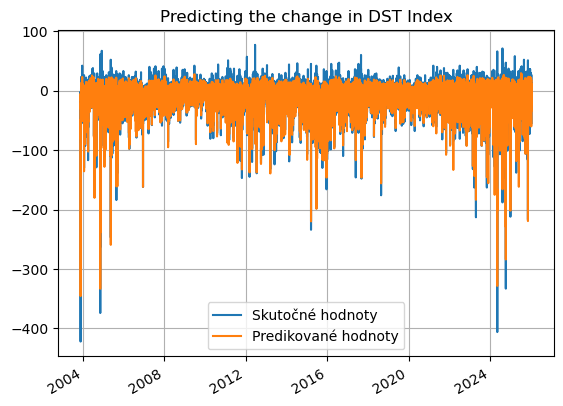

In [17]:
df = pd.DataFrame(data={"time": test['time1'][n_input:],"y_true": y_test_raw[n_input:] , "y_predict": y_pred.reshape(-1)})

df["residuals"] = df["y_true"] - df["y_predict"]
df["true_binary"] = (df["y_true"] <= -20).astype(int)
df["pred_binary"] = (df["y_predict"] <= CLASSIFICATION_THRESHOLD).astype(int)
df["y_persistence"] = df["y_true"].shift(shift)

plt.figure()
plt.title('Predicting the change in DST Index')
plt.plot(df['time'],df['y_true'], label='Skutočné hodnoty')
plt.plot(df['time'],df['y_predict'], label='Predikované hodnoty')
plt.legend()
plt.gcf().autofmt_xdate()
plt.grid(True)

In [18]:
TN, FP, FN, TP = cm.ravel()
ACC = (TP + TN) / (TP + TN + FP + FN)
MCC = matthews_corrcoef(y_test_binary, y_pred_binary_lstm)
print("ACC={}".format(ACC))
print("MCC={}".format(MCC))
df['y_persistance'] = df['y_true'].shift(shift)
df = df.dropna(subset=["y_true", "y_predict", "y_persistance"])

# Získame hodnoty zo stĺpcov
y_true = df["y_true"].values
y_pred_nn = df["y_predict"].values
y_pred_persistence = df["y_persistance"].values

# MAE a MSE pre neurónovú sieť
mae_nn = mean_absolute_error(y_true, y_pred_nn)
mse_nn = mean_squared_error(y_true, y_pred_nn)

# MAE a MSE pre perzistentný model
mae_persistence = mean_absolute_error(y_true, y_pred_persistence)
mse_persistence = mean_squared_error(y_true, y_pred_persistence)

# Porovnanie zlepšenia
improvement_mae = (mae_persistence - mae_nn) / mae_persistence * 100
improvement_mse = (mse_persistence - mse_nn) / mse_persistence * 100

# Výpis
print("Výkon NN:")
print(f"MAE: {mae_nn:.4f}, MSE: {mse_nn:.4f}")

print("Perzistentný model:")
print(f"MAE: {mae_persistence:.4f}, MSE: {mse_persistence:.4f}")

print("Zlepšenie oproti Persistence Modelu:")
print(f"MAE Improvement: {improvement_mae:.2f}%")
print(f"MSE Improvement: {improvement_mse:.2f}%")

ACC=0.9157748915965435
MCC=0.7447379007270319
Výkon NN:
MAE: 4.8556, MSE: 56.6492
Perzistentný model:
MAE: 5.2996, MSE: 68.9611
Zlepšenie oproti Persistence Modelu:
MAE Improvement: 8.38%
MSE Improvement: 17.85%


In [19]:
###########################################
# 1. LSTM predikcie (aligned s n_input)
###########################################

y_train_lstm = model.predict(train_generator).reshape(-1)
y_val_lstm   = model.predict(val_generator).reshape(-1)
y_test_lstm  = model.predict(test_generator).reshape(-1)

emb_model = Model(inputs=model.input, outputs=model.layers[-2].output)
emb_train = emb_model.predict(train_generator)
emb_val   = emb_model.predict(val_generator)
emb_test  = emb_model.predict(test_generator)

# aligned y_true (TimeseriesGenerator posúva o n_input)
y_train_true = y_train[n_input:]
y_val_true   = y_val[n_input:]
y_test_true  = y_test[n_input:]

print("Shapes LSTM:")
print("train:", y_train_lstm.shape, y_train_true.shape)
print("val:  ", y_val_lstm.shape,   y_val_true.shape)
print("test: ", y_test_lstm.shape,  y_test_true.shape)


###########################################
# 2. Reziduá (chyba LSTM)
###########################################

error_train = y_train_true - y_train_lstm
error_val   = y_val_true   - y_val_lstm

# globálna smerodajná odchýlka chýb (použijeme ju na "nafúknutie" intervalu)
sigma_global = np.std(np.concatenate([error_train, error_val]))
print("Global sigma (LSTM errors, scaled):", sigma_global)


###########################################
# 3. Vstupy pre GP (tie isté indexy ako reziduá)
###########################################

# embeddingy z predposlednej vrstvy LSTM modelu
X_train_emb = emb_train
X_val_emb   = emb_val
X_test_emb  = emb_test

# Spojenie train+val pre GP
X_gp_train = np.concatenate([X_train_emb, X_val_emb])
y_gp_train = np.concatenate([error_train, error_val])

X_test_gp = X_test_emb

print("Shapes GP:")
print("X_gp_train:", X_gp_train.shape)
print("y_gp_train:", y_gp_train.shape)
print("X_test_gp:", X_test_gp.shape)


###########################################
# 4. Gaussian Process (subsampling kvôli RAM)
###########################################

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

max_gp_points = 5000
if len(X_gp_train) > max_gp_points:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_gp_train), size=max_gp_points, replace=False)
    X_gp_sub = X_gp_train[idx]
    y_gp_sub = y_gp_train[idx]
    print(f"Using subsample of {len(X_gp_sub)} points for GP.")
else:
    X_gp_sub = X_gp_train
    y_gp_sub = y_gp_train
    print("Using all points for GP.")

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=20.0, length_scale_bounds=(1e-1, 1e3)) \
         + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    n_restarts_optimizer=2,
    random_state=42
)

print("Training GP on", len(X_gp_sub), "points...")
gp.fit(X_gp_sub, y_gp_sub)
print("GP fitted. Kernel:", gp.kernel_)


###########################################
# 5. Predikcia GP chyby + hybrid LSTM+GP
###########################################

y_gp_mean_err, y_gp_std_err = gp.predict(X_test_gp, return_std=True)

y_train_lstm = inverse_target(y_train_lstm.reshape(-1))
y_val_lstm   = inverse_target(y_val_lstm.reshape(-1))
y_test_lstm  = inverse_target(y_test_lstm.reshape(-1))

y_train_true = y_train_raw[n_input:]
y_val_true   = y_val_raw[n_input:]
y_test_true  = y_test_raw[n_input:]

y_gp_mean_err = y_gp_mean_err * target_scale
y_gp_std_err = y_gp_std_err * target_scale
sigma_global = sigma_global * target_scale

print("Global sigma (LSTM errors):", sigma_global)

y_hybrid_mean  = y_test_lstm + y_gp_mean_err

times_test = pd.to_datetime(test["time1"].iloc[n_input:])
sigma_series = pd.Series(y_gp_std_err, index=times_test)
sigma_smooth = sigma_series.rolling(window=6, center=True, min_periods=1).mean().values

sigma_effective = np.sqrt(sigma_smooth**2 + sigma_global**2)

#z = 1.96  # 95% interval
z = 3  # 99% interval
y_hybrid_lower = y_hybrid_mean - z * sigma_effective
y_hybrid_upper = y_hybrid_mean + z * sigma_effective

print("Hybrid prediction with smoothed, inflated interval ready.")

896/896 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step
759/759 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step
896/896 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step
224/224 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step
759/759 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step
Shapes LSTM:
train: (229338,) (229338,)
val:   (57321,) (57321,)
test:  (194182,) (194182,)
Global sigma (LSTM errors, scaled): 0.4029407
Shapes GP:
X_gp_train: (286659, 18)
y_gp_train: (286659,)
X_test_gp: (194182, 18)
Using subsample of 5000 points for GP.
Training GP on 5000 points...
GP fitted. Kernel: 1.1**2 * RBF(length_scale=0.281) + WhiteKernel(noise_level=0.598)
Global sigma (LSTM errors): 8.866271
Hybrid prediction with smoothed, inflated interval ready.


/opt/conda/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


  8/896 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step

 10/896 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step

 12/896 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step

...

759/759 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step


Shapes LSTM:
train: (229338,) (229338,)
val:   (57321,) (57321,)
test:  (194182,) (194182,)
Global sigma (LSTM errors): 9.326584939519021
Shapes GP:
X_gp_train: (286659, 2)
y_gp_train: (286659,)
X_test_gp: (194182, 2)


Using subsample of 5000 points for GP.
Training GP on 5000 points...


GP fitted. Kernel: 3.64**2 * RBF(length_scale=35.9) + WhiteKernel(noise_level=0.812)


Hybrid prediction with smoothed, inflated interval ready.


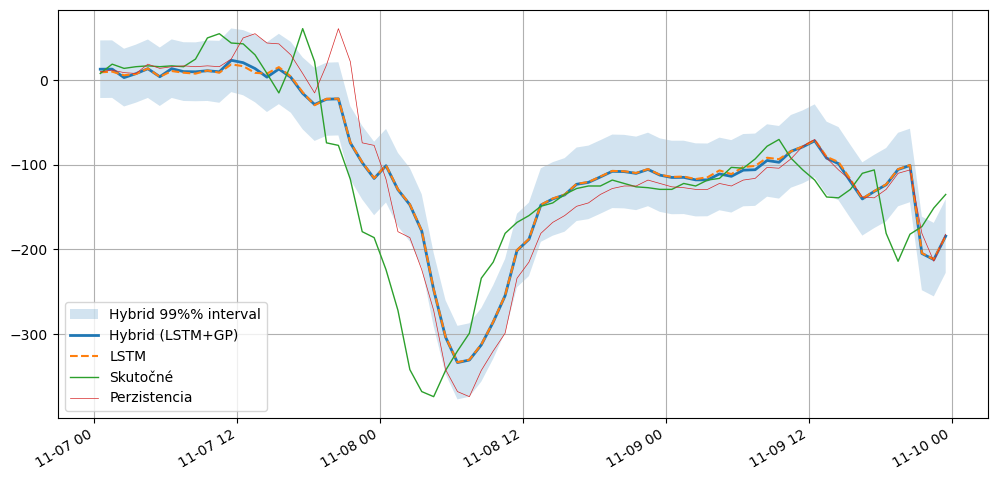

In [20]:
time_aligned = test["time1"][n_input:][shift:]

cols = [
    y_test_true[shift:],
    y_test_lstm[shift:],
    y_gp_mean_err[shift:],
    y_hybrid_mean[shift:],
    y_hybrid_lower[shift:],
    y_hybrid_upper[shift:],
    y_pred_persistence,
    time_aligned
]

L = min(len(x) for x in cols)

df = pd.DataFrame({
    "time": time_aligned[:L],
    "y_true": y_test_true[shift:][:L],
    "y_lstm": y_test_lstm[shift:][:L],
    "y_gp_error": y_gp_mean_err[shift:][:L],
    "y_hybrid": y_hybrid_mean[shift:][:L],
    "hybrid_lower": y_hybrid_lower[shift:][:L],
    "hybrid_upper": y_hybrid_upper[shift:][:L],
    "y_pred_persistence": y_pred_persistence[:L],
})




start_date = "2004-11-07"
end_date   = "2004-11-10"

df_range = df[(df["time"] >= start_date) & (df["time"] <= end_date)]

plt.figure(figsize=(12,6))
plt.fill_between(df_range["time"], df_range["hybrid_lower"], df_range["hybrid_upper"],
                 alpha=0.2, label="Hybrid 99%% interval")
plt.plot(df_range["time"], df_range["y_hybrid"], label="Hybrid (LSTM+GP)", linewidth=2)
plt.plot(df_range["time"], df_range["y_lstm"], label="LSTM", linestyle="--")
plt.plot(df_range["time"], df_range["y_true"], label="Skutočné", linewidth=1)
plt.plot(df_range["time"], df_range["y_pred_persistence"], label="Perzistencia", linewidth=0.5 )
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()
os.makedirs("datasets", exist_ok=True)
df.to_csv(os.path.join("datasets", f"prediction_comparison_{y_col}_LSTM_{n_input}H.csv"), index=False)

In [21]:
from sklearn.metrics import mean_absolute_error

# --- REGRESNÉ METRIKY ---
y_true_hybrid = df['y_true'].to_numpy()
y_pred_hybrid = df['y_hybrid'].to_numpy()

mse = mean_squared_error(y_true_hybrid, y_pred_hybrid)
mae = mean_absolute_error(y_true_hybrid, y_pred_hybrid)

# --- KLASIFIKAČNÉ METRIKY ---
CLASSIFICATION_THRESHOLD_PRED = CLASSIFICATION_THRESHOLD
y_true_binary = np.where(y_true_hybrid <= -20, 1, 0)
y_pred_binary = np.where(y_pred_hybrid <= CLASSIFICATION_THRESHOLD_PRED, 1, 0)

conf_matrix = confusion_matrix(y_true_binary, y_pred_binary)
mcc = matthews_corrcoef(y_true_binary, y_pred_binary)

# --- VÝSTUP ---
print("--- Regresné metriky (Hybridný model) ---")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

print(f"\n--- Klasifikačné metriky (Prah: {CLASSIFICATION_THRESHOLD_PRED} nT) ---")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

print("\nKonfúzna matica (Confusion Matrix):")
print("          | Predikcia 0 | Predikcia 1")
print("---------------------------------")
print(f"Skutočná 0 | {conf_matrix[0, 0]:>11} | {conf_matrix[0, 1]:>11}")
print(f"Skutočná 1 | {conf_matrix[1, 0]:>11} | {conf_matrix[1, 1]:>11}")

print("\nClassification Report (Trieda 1 je Búrka):")
print(classification_report(y_true_binary, y_pred_binary, target_names=['Trieda 0 (Normálna)', 'Trieda 1 (Búrka)']))

--- Regresné metriky (Hybridný model) ---
MSE: 61.5040
MAE: 5.1785

--- Klasifikačné metriky (Prah: -19.5 nT) ---
Matthews Correlation Coefficient (MCC): 0.7279

Konfúzna matica (Confusion Matrix):
          | Predikcia 0 | Predikcia 1
---------------------------------
Skutočná 0 |      143949 |        8097
Skutočná 1 |        9634 |       32497

Classification Report (Trieda 1 je Búrka):
                     precision    recall  f1-score   support

Trieda 0 (Normálna)       0.94      0.95      0.94    152046
   Trieda 1 (Búrka)       0.80      0.77      0.79     42131

           accuracy                           0.91    194177
          macro avg       0.87      0.86      0.86    194177
       weighted avg       0.91      0.91      0.91    194177



In [22]:
import os, json
import numpy as np
import os
import pandas as pd
from datetime import datetime
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, matthews_corrcoef, classification_report
)

OUT_CSV = "all_models_report.csv"

TRUE_CLASS_THRESHOLD = -20.0

PRED_CLASS_THRESHOLD = float(CLASSIFICATION_THRESHOLD)

meta = {
    "input_len_hours": float(globals().get("n_input", np.nan)),
    "forecast_horizon_hours": float(globals().get("shift", np.nan)),
    "target": str(globals().get("y_col", "DST")),
    "dataset": str(globals().get("dataset_name", "OMNI2_all")),
}

def _reg_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    return (
        float(mean_absolute_error(y_true[m], y_pred[m])),
        float(mean_squared_error(y_true[m], y_pred[m]))
    )

def _cls_metrics_from_dst(y_true_dst, y_pred_dst, true_thr, pred_thr):
    y_true_dst = np.asarray(y_true_dst).reshape(-1)
    y_pred_dst = np.asarray(y_pred_dst).reshape(-1)
    m = np.isfinite(y_true_dst) & np.isfinite(y_pred_dst)

    y_true_bin = (y_true_dst[m] <= true_thr).astype(int)
    y_pred_bin = (y_pred_dst[m] <= pred_thr).astype(int)

    acc = float(accuracy_score(y_true_bin, y_pred_bin))
    mcc = float(matthews_corrcoef(y_true_bin, y_pred_bin))
    rep = classification_report(y_true_bin, y_pred_bin, digits=4, zero_division=0)
    return acc, mcc, rep

def _improvement(model_err, base_err):
    return float(100.0 * (base_err - model_err) / base_err) if base_err != 0 else np.nan

def _append_row(csv_path, row):
    row_df = pd.DataFrame([row])
    if os.path.exists(csv_path):
        old = pd.read_csv(csv_path)
        out = pd.concat([old, row_df], ignore_index=True)
    else:
        out = row_df
    out.to_csv(csv_path, index=False)
    return out

required_cols = {"y_true", "y_lstm", "y_hybrid", "y_pred_persistence"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"df nemá potrebné stĺpce: {missing}. Aktuálne: {list(df.columns)}")

df_eval = df.dropna(subset=list(required_cols)).copy()

def log_one_model(nn_type, y_pred_col):
    y_true = df_eval["y_true"].to_numpy(dtype=float)
    y_pred = df_eval[y_pred_col].to_numpy(dtype=float)
    y_pers = df_eval["y_pred_persistence"].to_numpy(dtype=float)

    mae_model, mse_model = _reg_metrics(y_true, y_pred)
    mae_pers,  mse_pers  = _reg_metrics(y_true, y_pers)

    mae_imp = _improvement(mae_model, mae_pers)
    mse_imp = _improvement(mse_model, mse_pers)

    acc, mcc, rep_txt = _cls_metrics_from_dst(
        y_true, y_pred,
        true_thr=TRUE_CLASS_THRESHOLD,
        pred_thr=PRED_CLASS_THRESHOLD
    )

    row = {
        "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds"),
        "nn_type": nn_type,  # LSTM vs LSTM+GP

        # meta
        **meta,

        # prahy
        "true_class_threshold_nt": float(TRUE_CLASS_THRESHOLD),
        "pred_class_threshold_nt": float(PRED_CLASS_THRESHOLD),

        # klasifikácia
        "ACC": float(acc),
        "MCC": float(mcc),
        "classification_report": json.dumps({"text": rep_txt}, ensure_ascii=False),

        # regresia
        "MAE_model": float(mae_model),
        "MSE_model": float(mse_model),
        "MAE_persistence": float(mae_pers),
        "MSE_persistence": float(mse_pers),
        "MAE_improvement_pct": float(mae_imp),
        "MSE_improvement_pct": float(mse_imp),
    }

    print(f"\n===== {nn_type} =====")
    print(f"ACC={row['ACC']}")
    print(f"MCC={row['MCC']}")
    print("Výkon NN:")
    print(f"MAE: {row['MAE_model']:.4f}, MSE: {row['MSE_model']:.4f}")
    print("Perzistentný model:")
    print(f"MAE: {row['MAE_persistence']:.4f}, MSE: {row['MSE_persistence']:.4f}")
    print("Zlepšenie oproti Persistence Modelu:")
    print(f"MAE Improvement: {row['MAE_improvement_pct']:.2f}%")
    print(f"MSE Improvement: {row['MSE_improvement_pct']:.2f}%")
    print("\nKlasifikačný report:")
    print(rep_txt)

    return row

rows = [
    log_one_model("LSTM", "y_lstm"),
    log_one_model("LSTM+GP", "y_hybrid"),
]

out_df = None
for r in rows:
    out_df = _append_row(OUT_CSV, r)

print(f"\nSaved/updated: {OUT_CSV}")
out_df.tail(10)


===== LSTM =====
ACC=0.9157727228250514
MCC=0.7447362012381571
Výkon NN:
MAE: 4.8556, MSE: 56.6492
Perzistentný model:
MAE: 5.2996, MSE: 68.9611
Zlepšenie oproti Persistence Modelu:
MAE Improvement: 8.38%
MSE Improvement: 17.85%

Klasifikačný report:
              precision    recall  f1-score   support

           0     0.9347    0.9595    0.9469    152046
           1     0.8382    0.7581    0.7962     42131

    accuracy                         0.9158    194177
   macro avg     0.8865    0.8588    0.8715    194177
weighted avg     0.9138    0.9158    0.9142    194177


===== LSTM+GP =====
ACC=0.908686404672026
MCC=0.7278768422847
Výkon NN:
MAE: 5.1785, MSE: 61.5040
Perzistentný model:
MAE: 5.2996, MSE: 68.9611
Zlepšenie oproti Persistence Modelu:
MAE Improvement: 2.29%
MSE Improvement: 10.81%

Klasifikačný report:
              precision    recall  f1-score   support

           0     0.9373    0.9467    0.9420    152046
           1     0.8005    0.7713    0.7857     42131

    ac

/tmp/ipykernel_258667/3102912212.py:84: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds"),
/tmp/ipykernel_258667/3102912212.py:84: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds"),


,timestamp_utc,nn_type,input_len_hours,forecast_horizon_hours,target,dataset,true_class_threshold_nt,pred_class_threshold_nt,ACC,MCC,classification_report,MAE_model,MSE_model,MAE_persistence,MSE_persistence,MAE_improvement_pct,MSE_improvement_pct
14,2026-04-25T23:03:03,LSTM,6.0,3.0,DST+3,OMNI2_all,-20.0,-20.0,0.915433,0.744636,"{""text"": "" precision recall f...",4.941702,58.039948,5.299620,68.959107,6.753653,15.834252
15,2026-04-25T23:03:03,LSTM+GP,6.0,3.0,DST+3,OMNI2_all,-20.0,-20.0,0.913116,0.739509,"{""text"": "" precision recall f...",5.117792,62.310723,5.299620,68.959107,3.430976,9.641053
16,2026-04-26T00:03:57,LSTM,24.0,2.0,DST+2,OMNI2_all,-20.0,-19.5,0.932756,0.796934,"{""text"": "" precision recall f...",3.896367,36.383390,4.211590,43.257647,7.484647,15.891425
17,2026-04-26T00:03:57,LSTM+GP,24.0,2.0,DST+2,OMNI2_all,-20.0,-19.5,0.928837,0.787369,"{""text"": "" precision recall f...",4.096409,39.654321,4.211590,43.257647,2.734848,8.329916
18,2026-04-26T08:08:23,LSTM,12.0,3.0,DST+3,OMNI2_all,-20.0,-20.7,0.915925,0.743147,"{""text"": "" precision recall f...",4.883529,56.770808,5.299650,68.960383,7.851861,17.676200
19,2026-04-26T08:08:23,LSTM+GP,12.0,3.0,DST+3,OMNI2_all,-20.0,-20.7,0.909184,0.723067,"{""text"": "" precision recall f...",5.233479,63.670637,5.299650,68.960383,1.248603,7.670702
20,2026-04-26T09:23:12,LSTM,24.0,3.0,DST+3,OMNI2_all,-20.0,-19.1,0.916357,0.749534,"{""text"": "" precision recall f...",4.817674,55.656937,5.299679,68.962605,9.094983,19.294033
21,2026-04-26T09:23:12,LSTM+GP,24.0,3.0,DST+3,OMNI2_all,-20.0,-19.1,0.910038,0.731958,"{""text"": "" precision recall f...",5.128815,60.961466,5.299679,68.962605,3.224051,11.602141
22,2026-04-26T09:23:49,LSTM,18.0,3.0,DST+3,OMNI2_all,-20.0,-19.5,0.915773,0.744736,"{""text"": "" precision recall f...",4.855584,56.649168,5.299618,68.961051,8.378616,17.853386
23,2026-04-26T09:23:49,LSTM+GP,18.0,3.0,DST+3,OMNI2_all,-20.0,-19.5,0.908686,0.727877,"{""text"": "" precision recall f...",5.178455,61.503963,5.299618,68.961051,2.286268,10.813478
